# Example: Using slack variables

This example shows you how to enable slack variables on import/export constraints

Slack variables can be used in situations where we do not know beforehand whether a problem is feasible, and if it is not feasible, we would like the solver to return a solution and be able to interrogate by how much the relevant constraints were violated. We do this by introducing slack variables into the relevant constraints and applying a large cost to the maximum slack value.

## Imports

Import everything we need.

In [66]:
import numpy as np

from echo.models.base import Node, OptimisationGraph
from echo.models.agnostic import FlexPort
from echo.models.electrical import ElectricalGeneration, Inverter
from echo.configuration import Units
from echo.optimiser import optimise
from echo.models.scenario import EngineSettings, ScenarioSettings

### Create a simple network

We create a system where uncurtailable solar is fed through a connection point that has an export constraint.


In [67]:
time_periods = 96  # total number of intervals
interval_duration = 15  # Duration in mins of each interval
expansion_periods = 1  # Number of planning intervals - in echo V1, set to 1 always

scenario_settings = ScenarioSettings(
    interval_duration=interval_duration,
    number_of_intervals=time_periods,
    number_of_expansion_intervals=expansion_periods,
    discount_rate=0,
)

Next we define the PV generation data.

*Note:* The number of elements in the `pv_array` should be match the number of time periods i.e. `96`.

In [68]:
pv_array = 2 * np.array(
    [
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.05,
        0.23,
        0.52,
        0.74,
        0.71,
        0.63,
        0.68,
        0.97,
        0.01,
        0.52,
        0.83,
        0.83,
        0.79,
        1.22,
        1.36,
        1.27,
        1.42,
        1.97,
        2.56,
        2.91,
        3.24,
        3.8,
        4.3,
        4.62,
        4.84,
        4.6,
        4.17,
        3.77,
        3.76,
        3.38,
        2.64,
        1.96,
        1.76,
        1.85,
        2.4,
        3.82,
        5.13,
        4.97,
        5.02,
        5.43,
        5.32,
        3.56,
        1.75,
        1.43,
        1.65,
        1.69,
        2.3,
        2.71,
        2.41,
        2.63,
        2.6,
        1.9,
        0.78,
        0.13,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
    ]
)

pv_array *= -1  # use positive load convention, so solar gen is negative

Create the nodes (grid, inverter, solar) and the ports which will connect them.

In [69]:
grid = Node(node_name="grid")  # create node representing upstream grid
grid.add_port("grid", FlexPort(units=Units.KW))

inverter = Inverter(
    node_name="inverter",
    max_import=None,
    max_export=None,
    dc_ac_efficiency=1,
    ac_dc_efficiency=1,
    ac_port_name="inv",  # add a port with name 'inv' that is used to connect upstream/ac side
    dc_port_names=["pv"],  # add a port with name 'pv' for us to connect the pv node into
)


# create a node for the solar
solar = Node(node_name="solar")
solar_port = ElectricalGeneration()  # create an electrical generation object
solar_port.curtailable = False  # set whether this can be curtailed or not
solar_port.add_generation_profile_from_array(pv_array, expansion_periods)
solar.ports["pv"] = solar_port  # add the solar port to the dictionary of node ports

Create the graph(network) by adding the nodes and joining the nodes via their ports.

In [70]:
network = OptimisationGraph()
network.add_node_obj([grid, inverter, solar])

network.connect_ports_and_create_edge(grid.ports["grid"], inverter.ports["inv"])
network.connect_ports_and_create_edge(inverter.ports["pv"], solar.ports["pv"])

We can visualise our small site as a matplotlib figure. The labels are obtained from the `node_name`s. We also add some styling (through the `style` dictionary) to improve the visual appearance.

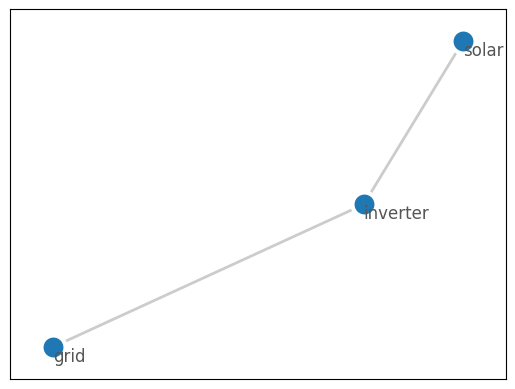

In [71]:
import matplotlib.pyplot as plt

network_figure = plt.figure()
network_axes = network_figure.add_subplot()
style = {
    "edgecolors": "#FFFFFF",  # node border color
    "linewidths": 3,  # node border width
    "edge_color": "#CCCCCC",  # edge color of edges
    "width": 2,  # edge width
    "horizontalalignment": "left",  # label horizontal position
    "verticalalignment": "top",  # label vertical position
    "font_color": "#555555",  # label text color
}
network.draw_on_axes(axes=network_axes, with_labels=True, **style)
plt.show()

### Set an export constraint on the grid connection port
We must be careful to pick the correct port here, so that we can get the import/export constraint correct.
Let's pick the inverter port that connects to the grid. We want to apply an export constraint, so we set `max_export` to our limit (-5), and leave `max_import=None`. Note that the export constraint value must be negative to adhere to positive load convention.

Alternatively, you could apply the same constraint on the grid node port that connects to the inverter. In this case, we would specify `max_export=None`, and `max_import=5`.

We can set the flow constraint by using `.set_flow_constraint()`, and also enable a slack variable on this constraint.

In [72]:
constrained_port = inverter.ports["inv"]  # get the port object
constrained_port.set_flow_constraints(max_import=None, max_export=-5.0, slack=True)  # set a flow constraint

### Setup and run the optimiser

Here we are going to use [cplex](https://www.ibm.com/products/ilog-cplex-optimization-studio/cplex-optimizer) solver.

In [73]:
engine_settings = EngineSettings(
    engine="cplex",
    engine_executable="",
    bigM=5000000,  # This value has been arbitrarily chosen
    smallM=0.0001,  # This value has been arbitrarily chosen
)

Perform the optimisation, passing in all the required information (solver, scenario, network and objectives)

In [74]:
optimise_results = optimise(
    scenario_settings=scenario_settings,
    engine_settings=engine_settings,
    graph=network,
)


Welcome to IBM(R) ILOG(R) CPLEX(R) Interactive Optimizer 22.1.1.0
  with Simplex, Mixed Integer & Barrier Optimizers
5725-A06 5725-A29 5724-Y48 5724-Y49 5724-Y54 5724-Y55 5655-Y21
Copyright IBM Corp. 1988, 2022.  All Rights Reserved.

Type 'help' for a list of available commands.
Type 'help' followed by a command name for more
information on commands.

CPLEX> Logfile 'cplex.log' closed.
Logfile '/tmp/tmp75muurpw.cplex.log' open.
CPLEX> Problem '/tmp/tmppya4wd7r.pyomo.lp' read.
Read time = 0.00 sec. (0.06 ticks)
CPLEX> Problem name         : /tmp/tmppya4wd7r.pyomo.lp
Objective sense      : Minimize
Variables            :     673  [Nneg: 193,  Free: 288,  Binary: 96,
                                 Other: 96]
Objective nonzeros   :      97
Linear constraints   :     768  [Less: 288,  Greater: 96,  Equal: 384]
  Nonzeros           :    1632
  RHS nonzeros       :     246

Variables            : Min LB: 0.000000         Max UB: 1.000000       
Objective nonzeros   : Min   : 500000.0     

### Look at results
The optimiser will create an indexed slack variable, which equals the slack taken up at each time interval.

It also creates a max slack variable, which equals the maximum slack over all optimisation time periods.

If there is an import and export constraint, echo will create a separate import slack variable and export slack variable.

In this case, because we only set an export constraint, we will only have an export slack variable.

We can look at this variable and see that in the middle of the day when solar generation is high and uncurtailable, we run into the export constraint of 5 kW, and the slack variable `.export_slack` has a non-zero value. We can see the maximum violation, given by  `.max_export_slack`.

In [75]:
inverter_output = optimise_results.values(constrained_port.port_name)
slack = optimise_results.values(constrained_port.export_slack)
max_slack = optimise_results.values(constrained_port.export_slack_max)
print("Inverter output:\n", inverter_output)
print("Export slack:\n", slack)
print("Max export slack:\n", max_slack)

Inverter output:
 [  0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
   0.     0.     0.     0.     0.     0.     0.     0.    -0.1   -0.46
  -1.04  -1.48  -1.42  -1.26  -1.36  -1.94  -0.02  -1.04  -1.66  -1.66
  -1.58  -2.44  -2.72  -2.54  -2.84  -3.94  -5.12  -5.82  -6.48  -7.6
  -8.6   -9.24  -9.68  -9.2   -8.34  -7.54  -7.52  -6.76  -5.28  -3.92
  -3.52  -3.7   -4.8   -7.64 -10.26  -9.94 -10.04 -10.86 -10.64  -7.12
  -3.5   -2.86  -3.3   -3.38  -4.6   -5.42  -4.82  -5.26  -5.2   -3.8
  -1.56  -0.26   0.     0.     0.     0.     0.     0.     0.     0.
   0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
   0.     0.     0.     0.     0.     0.  ]
Export slack:
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.12 0.82 1.48 2.6  3.6  4.24
 4.68 4.2  3.34 2.54 2.52 1.76 0.28 0.   0.   0.   0.   2.64 5.26 4.94
 5.04 5.86 5

## Plot the results
Plot the data from the previous cell.

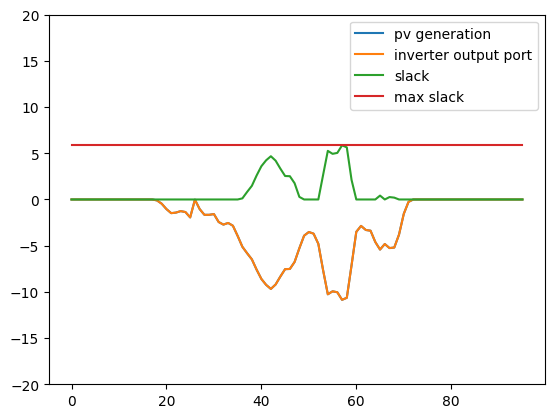

In [76]:
plt.plot(pv_array, label="pv generation")
plt.plot(inverter_output, label="inverter output port")
plt.plot(slack, label="slack")
plt.plot([max_slack] * time_periods, label="max slack")
plt.legend()
plt.ylim([-20, 20])
plt.show()